# Comparative Analysis of Machine Learning Models

## Evaluation Metrics Comparison

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---------|---------:|---------:|---------:|---------:|---------:|
| Logistic Regression | 0.7492 | 0.6674 | 0.5299 | 0.5907 | 0.8129 |
| Random Forest | 0.8395 | 0.7939 | 0.7163 | 0.7531 | 0.9054 |
| XGBoost | 0.8419 | 0.7891 | **0.7332** | **0.7601** | 0.9104 |
| MLP | **0.8426** | 0.8013 | 0.7174 | 0.7570 | 0.9105 |
| TabNet | 0.8420 | **0.8086** | 0.7041 | 0.7528 | **0.9108** |
| TabTransformer | 0.8418 | 0.7895 | 0.7320 | 0.7597 | 0.9104 |

## Accuracy Analysis

Accuracy measures the proportion of correctly classified events among all events.

- Logistic Regression achieved the lowest accuracy (74.92%).
- MLP achieved the highest accuracy (84.26%).
- Random Forest, XGBoost, TabNet, and TabTransformer achieved very similar accuracy values around 84%.
- The results indicate that advanced machine learning and deep learning models significantly outperform the baseline linear model.

## Precision Analysis

Precision measures the proportion of predicted Higgs events that are actually Higgs events.

- TabNet achieved the highest precision (80.86%).
- MLP achieved the second-highest precision (80.13%).
- High precision indicates fewer false positive predictions.
- TabNet is the most reliable model when predicting Higgs events.

## Recall Analysis

Recall measures the proportion of actual Higgs events correctly identified by the model.

- XGBoost achieved the highest recall (73.32%).
- TabTransformer achieved a similar recall (73.20%).
- Logistic Regression achieved the lowest recall (52.99%).
- Higher recall is important in particle physics because missing true Higgs events can reduce scientific discovery potential.

## F1-Score Analysis

The F1-Score provides a balance between Precision and Recall.

- XGBoost achieved the highest F1-Score (0.7601).
- TabTransformer achieved a very similar F1-Score (0.7597).
- MLP also performed competitively with an F1-Score of 0.7570.
- These results indicate that XGBoost provides the best balance between identifying Higgs events and minimizing false positives.

## ROC-AUC Analysis

ROC-AUC measures the model's ability to distinguish between Higgs signal and background events across all classification thresholds.

- TabNet achieved the highest ROC-AUC score (0.9108).
- MLP achieved a ROC-AUC score of 0.9105.
- XGBoost and TabTransformer achieved ROC-AUC scores of 0.9104.
- Random Forest achieved a strong ROC-AUC score of 0.9054.
- Logistic Regression achieved the lowest ROC-AUC score of 0.8129.

The small difference among the top four models indicates that they possess nearly equivalent discriminative power.

## Overall Ranking

Based on ROC-AUC:

1. TabNet (0.9108)
2. MLP (0.9105)
3. XGBoost (0.9104)
4. TabTransformer (0.9104)
5. Random Forest (0.9054)
6. Logistic Regression (0.8129)

## Final Conclusion

All advanced models achieved ROC-AUC scores greater than 0.90, demonstrating strong predictive performance for Higgs Boson classification. TabNet achieved the highest ROC-AUC and precision, while XGBoost achieved the highest recall and F1-score. Considering both predictive performance and explainability requirements, XGBoost was selected as the primary model for SHAP analysis, LIME analysis, and feature selection for subsequent Quantum Machine Learning models.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "MLP",
        "TabNet",
        "TabTransformer"
    ],
    "Accuracy": [
        0.7492, 0.8395, 0.8427,
        0.8426, 0.8420, 0.8418
    ],
    "Precision": [
        0.6674, 0.7939, 0.7905,
        0.8013, 0.8086, 0.7895
    ],
    "Recall": [
        0.5299, 0.7163, 0.7343,
        0.7174, 0.7041, 0.7320
    ],
    "F1 Score": [
        0.5907, 0.7531, 0.7614,
        0.7570, 0.7528, 0.7597
    ],
    "ROC-AUC": [
        0.8129, 0.9054, 0.9105,
        0.9105, 0.9108, 0.9104
    ]
})

results.sort_values(
    by="ROC-AUC",
    ascending=False
)



,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,TabNet,0.8420,0.8086,0.7041,0.7528,0.9108
2,XGBoost,0.8427,0.7905,0.7343,0.7614,0.9105
3,MLP,0.8426,0.8013,0.7174,0.7570,0.9105
5,TabTransformer,0.8418,0.7895,0.7320,0.7597,0.9104
1,Random Forest,0.8395,0.7939,0.7163,0.7531,0.9054
0,Logistic Regression,0.7492,0.6674,0.5299,0.5907,0.8129


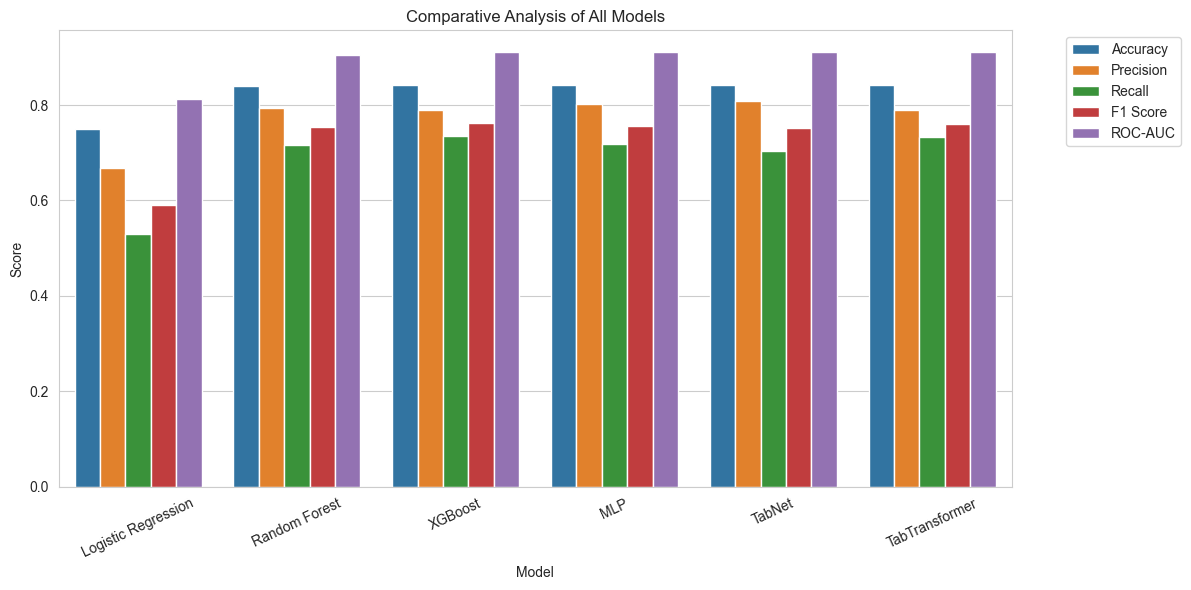

In [6]:
results_melted = results.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title(
    "Comparative Analysis of All Models"
)

plt.ylabel("Score")
plt.xticks(rotation=25)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../results/plots/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

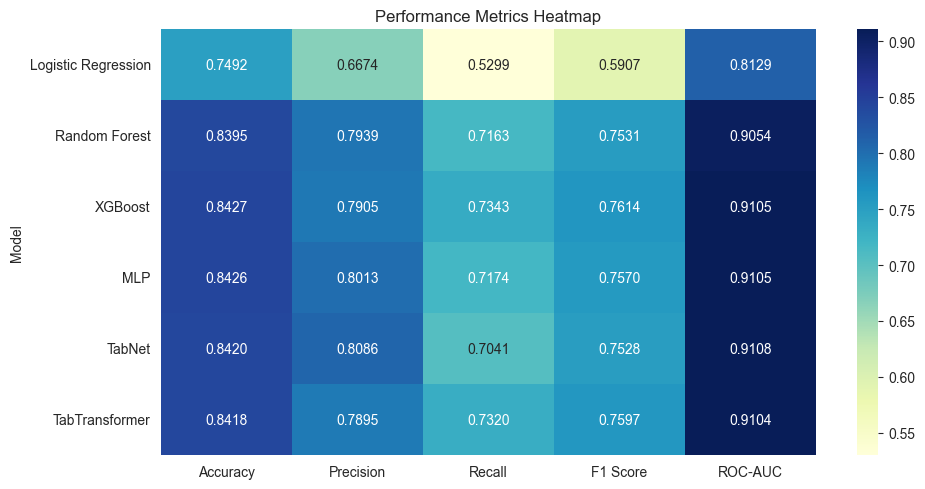

In [7]:
plt.figure(figsize=(10,5))

sns.heatmap(
    results.set_index("Model"),
    annot=True,
    cmap="YlGnBu",
    fmt=".4f"
)

plt.title(
    "Performance Metrics Heatmap"
)

plt.tight_layout()

plt.savefig(
    "../results/plots/model_comparison_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ROC-AUC comparison chart

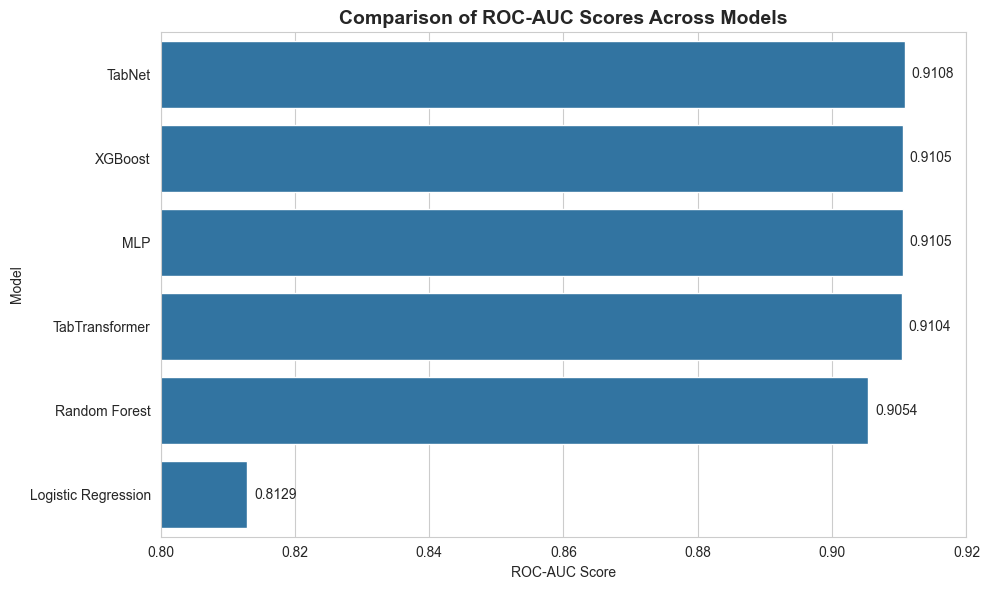

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

roc_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "MLP",
        "TabNet",
        "TabTransformer"
    ],
    "ROC_AUC": [
        0.8129,
        0.9054,
        0.9105,
        0.9105,
        0.9108,
        0.9104
    ]
})

roc_results = roc_results.sort_values(
    by="ROC_AUC",
    ascending=False
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=roc_results,
    x="ROC_AUC",
    y="Model"
)

for i, value in enumerate(roc_results["ROC_AUC"]):
    ax.text(
        value + 0.001,
        i,
        f"{value:.4f}",
        va="center"
    )

plt.title(
    "Comparison of ROC-AUC Scores Across Models",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("ROC-AUC Score")
plt.ylabel("Model")

plt.xlim(0.80, 0.92)

plt.tight_layout()

plt.savefig(
    "../results/plots/roc_auc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()